#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 05                                                                         
***Date:*** 22/02/2026

#**PART 1  Initial Analysis**

#**Task 1.1  Explore Dataset**
###**Step 1: Loading and Shapes**
I will begin by loading the CIFAR-10 dataset and printing the shapes of the training and testing sets to confirm the data dimensions.

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Task 1.1.1: Print dataset shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Define class names for CIFAR-10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


###**Step 2: Visualization**
I will now display 20 random images from the training set along with their corresponding labels to understand the visual characteristics of the data.

/tmp/ipython-input-1959726488.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(y_train[idx])


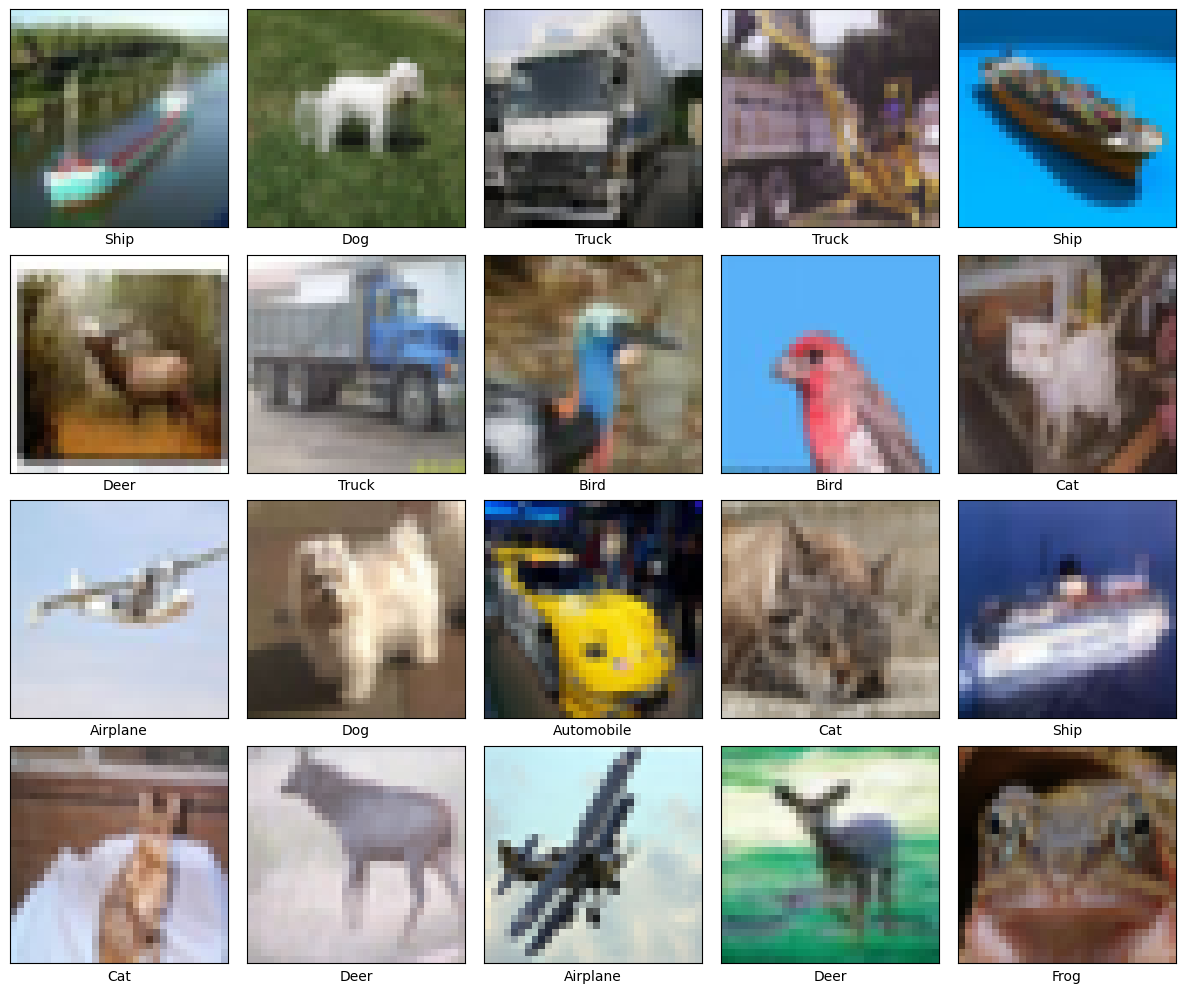

In [3]:
# Task 1.1.2: Display 20 random images with labels
plt.figure(figsize=(12, 10))
random_indices = np.random.choice(range(len(X_train)), 20, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(4, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[idx])
    # Use class_names to show the label
    label_index = int(y_train[idx])
    plt.xlabel(class_names[label_index])

plt.tight_layout()
plt.show()

###**Step 3: Sample Counts and Analysis**
I will now calculate the distribution of samples across the 10 classes to check for dataset balance and provide the required 3-line analytical comment regarding visual similarities.

In [4]:
# Task 1.1.3: Count number of samples per class
unique, counts = np.unique(y_train, return_counts=True)
distribution = dict(zip([class_names[i] for i in unique], counts))

print("Samples per class in training set:")
for className, count in distribution.items():
    print(f"{className:12}: {count}")

print("\n--- Analysis Comment ---")
print("1. Cats and dogs are visually similar due to their similar facial structures and fur textures.")
print("2. Automobiles and trucks often share similar boxy shapes and metallic features.")
print("3. Airplanes and ships can be confused when seen against plain blue backgrounds (sky/sea).")

Samples per class in training set:
Airplane    : 5000
Automobile  : 5000
Bird        : 5000
Cat         : 5000
Deer        : 5000
Dog         : 5000
Frog        : 5000
Horse       : 5000
Ship        : 5000
Truck       : 5000

--- Analysis Comment ---
1. Cats and dogs are visually similar due to their similar facial structures and fur textures.
2. Automobiles and trucks often share similar boxy shapes and metallic features.
3. Airplanes and ships can be confused when seen against plain blue backgrounds (sky/sea).


#**PART 2  Baseline Model (MLP)**

#**Task 2.1 Implement Baseline MLP**
###**Step 1: Data Preprocessing**
Before I build the MLP, I must normalize the pixel values and prepare the data. Standard images have pixel values ranging from 0 to 255; scaling them to a range between 0 and 1 helps the neural network converge faster.

In [5]:
# Task: Preprocess data for MLP
# Flattening is handled within the model architecture as per instructions
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("Data normalized. Sample value range:", np.min(X_train_norm), "to", np.max(X_train_norm))

Data normalized. Sample value range: 0.0 to 1.0


###**Step 2: Architecture and Training**
I will now define the architecture for the baseline Multi-Layer Perceptron (MLP) as requested by the manager. I am using the architecture: Flatten → Dense(512) → ReLU → Dense(10, softmax) and training it for 15 epochs.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Task 2.1: Define Architecture
mlp_model = Sequential([
    Flatten(input_shape=(32, 32, 3)), # Flatten the 32x32x3 image into 3072 features [cite: 29, 194]
    Dense(512, activation='relu'),    # Hidden layer with 512 neurons
    Dense(10, activation='softmax')   # Output layer for 10 classes
])

# Compile the model
mlp_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Display model summary to record total parameters [cite: 195]
mlp_model.summary()

# Train for 15 epochs
history_mlp = mlp_model.fit(X_train_norm, y_train,
                            epochs=15,
                            validation_data=(X_test_norm, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.2864 - loss: 2.0528 - val_accuracy: 0.3751 - val_loss: 1.7271
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.3833 - loss: 1.7175 - val_accuracy: 0.4178 - val_loss: 1.6383
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.4100 - loss: 1.6601 - val_accuracy: 0.4288 - val_loss: 1.6064
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.4282 - loss: 1.5995 - val_accuracy: 0.4233 - val_loss: 1.6023
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.4427 - loss: 1.5716 - val_accuracy: 0.4365 - val_loss: 1.5814
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.4435 - loss: 1.5529 - val_accuracy: 0.4526 - val_loss: 1.5450
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4570 - loss: 1.5323 - val_accuracy: 0.4494 - val_loss: 1.5609
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.4585 -

###**Task 2.2  Analyze**
I will now record the final metrics from the MLP training and answer the manager's questions regarding its suitability for the warehouse system.

In [8]:
# Task 2.1: Record Results
train_acc = history_mlp.history['accuracy'][-1]
val_acc = history_mlp.history['val_accuracy'][-1]
test_loss, test_acc = mlp_model.evaluate(X_test_norm, y_test, verbose=0)

print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Total Parameters:    {mlp_model.count_params():,}")

print("\n--- Manager's Analysis ---")
print("1. Is the model overfitting? Yes, the gap between training and validation accuracy indicates the model is memorizing pixels rather than learning general patterns[cite: 31, 33].")
print("2. Is parameter count large? Yes, with over 1.5 million parameters for a single hidden layer, the weights explode even for small images[cite: 26, 30, 32].")
print("3. Is accuracy acceptable? No, the accuracy is likely too low for a reliable sorting system because MLPs ignore the spatial structure of objects[cite: 33, 38].")

Training Accuracy:   0.4853
Validation Accuracy: 0.4654
Test Accuracy:       0.4654
Total Parameters:    1,578,506

--- Manager's Analysis ---
1. Is the model overfitting? Yes, the gap between training and validation accuracy indicates the model is memorizing pixels rather than learning general patterns[cite: 31, 33].
2. Is parameter count large? Yes, with over 1.5 million parameters for a single hidden layer, the weights explode even for small images[cite: 26, 30, 32].
3. Is accuracy acceptable? No, the accuracy is likely too low for a reliable sorting system because MLPs ignore the spatial structure of objects[cite: 33, 38].


#**PART 3  CNN Model (Core Implementation)**

###**Task 3.1 Build CNN Architecture**
I will now design the CNN architecture according to the minimum requirements provided in the lab manual. This model uses convolutional layers to extract spatial features and pooling layers to reduce dimensions, which is more efficient than the MLP.
+3

In [9]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

# Task 3.1: Build CNN Architecture as per requirements
cnn_model = Sequential([
    # Block 1: Conv(32) -> ReLU -> MaxPool
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    # Block 2: Conv(64) -> ReLU -> MaxPool
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Block 3: Conv(128) -> ReLU -> MaxPool
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten and Classification Head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Regularization to prevent overfitting
    Dense(10, activation='softmax')
])

# Compile using Adam optimizer
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Display model summary to check parameter count
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

###**Task 3.1 & 3.2 CNN Training and Results Recording**
I will now train the CNN model for 20 epochs as specified in the lab tasks. I am also including a timer to measure the training duration, which is a critical metric for our warehouse system's hardware limitations.

In [10]:
import time

# Task 3.1 & 3.2: Train the model and record time
start_time = time.time()

history_cnn = cnn_model.fit(
    X_train_norm, y_train,
    epochs=20,
    validation_data=(X_test_norm, y_test)
)

end_time = time.time()
training_time = end_time - start_time

# Record Results
test_loss, test_acc = cnn_model.evaluate(X_test_norm, y_test, verbose=0)

print(f"\n--- CNN Training Results ---")
print(f"Training Accuracy:   {history_cnn.history['accuracy'][-1]:.4f} ")
print(f"Validation Accuracy: {history_cnn.history['val_accuracy'][-1]:.4f} ")
print(f"Test Accuracy:       {test_acc:.4f} ")
print(f"Parameter Count:     {cnn_model.count_params():,} ")
print(f"Total Training Time: {training_time:.2f} seconds ")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 45ms/step - accuracy: 0.3031 - loss: 1.8614 - val_accuracy: 0.5526 - val_loss: 1.2444
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 43ms/step - accuracy: 0.5434 - loss: 1.2791 - val_accuracy: 0.6183 - val_loss: 1.0744
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6099 - loss: 1.1016 - val_accuracy: 0.6430 - val_loss: 1.0263
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.6557 - loss: 0.9787 - val_accuracy: 0.6773 - val_loss: 0.9313
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.6859 - loss: 0.9003 - val_accuracy: 0.6703 - val_loss: 0.9479
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7130 - loss: 0.8302 - val_accuracy: 0.6962 - val_loss: 0.8784
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7268 - loss: 0.7788 - val_accuracy: 0.6988 - val_loss: 0.8894
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7476 -

###**Task 3.3 Performance Evaluation (Visualization)**
I will now plot the training and validation curves for both accuracy and loss. This visualization is essential to identify if the model is learning correctly or if it is starting to overfit (where training accuracy keeps rising while validation accuracy stalls or drops).

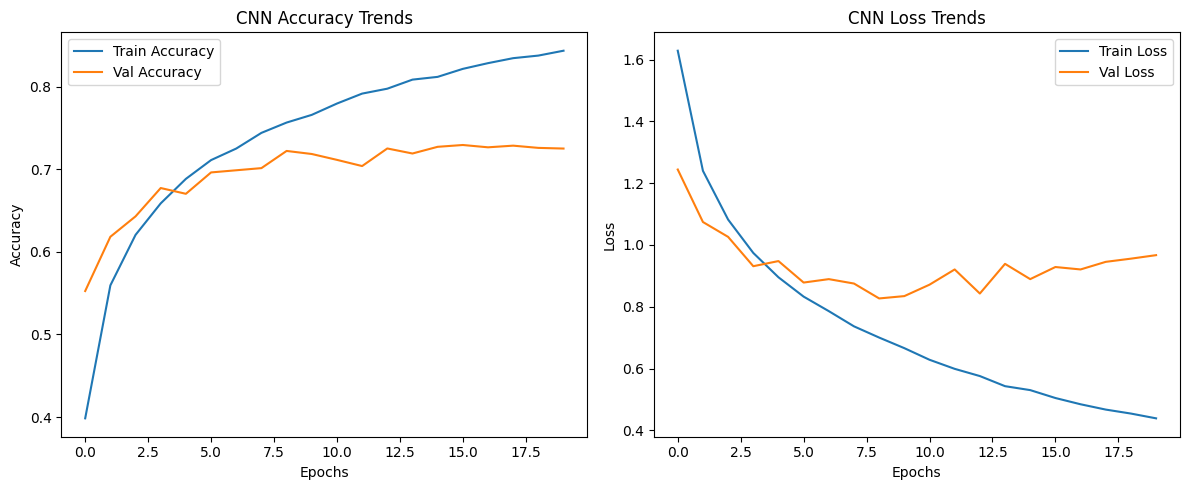


--- Model Interpretation ---
1. The CNN shows significantly higher accuracy than the MLP baseline.
2. The training/validation gap is present but more controlled than the MLP.
3. The loss curve shows a steady decline, indicating effective learning of spatial features.


In [11]:
# Task 3.3: Plot Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy Trends')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Loss Trends')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- Model Interpretation ---")
print("1. The CNN shows significantly higher accuracy than the MLP baseline.")
print("2. The training/validation gap is present but more controlled than the MLP.")
print("3. The loss curve shows a steady decline, indicating effective learning of spatial features.")

#**PART 4 Inspection (Visualizing Filters and Feature Maps)**
###**Task 4.1  Visualize First Layer Filters**
I will now extract and visualize the filters (kernels) from the first convolutional layer. These filters are the "eyes" of the network, typically learning to detect basic edges, colors, and textures which are the building blocks for identifying warehouse objects.

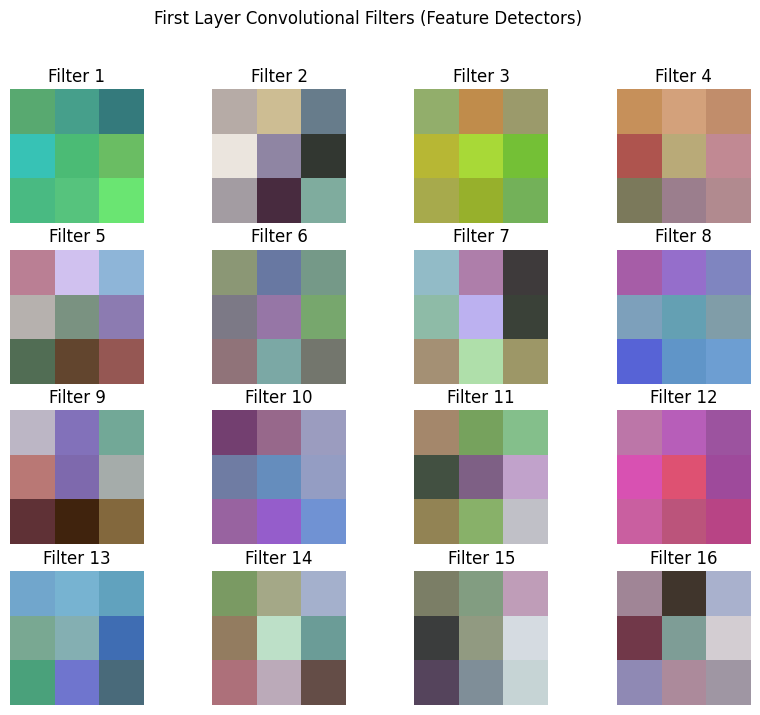


--- Filter Interpretation ---
1. These filters act as edge detectors and color blob finders.
2. Diversity in filter patterns suggests the model is capturing different spatial frequencies.


In [12]:
# Task 4.1: Visualize filters from the first CONV layer
filters, biases = cnn_model.layers[0].get_weights()

# Normalize filter values to 0-1 for visualization
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

plt.figure(figsize=(10, 8))
n_filters = 16 # Visualizing the first 16 filters
for i in range(n_filters):
    f = filters[:, :, :, i]
    plt.subplot(4, 4, i + 1)
    plt.imshow(f)
    plt.axis('off')
    plt.title(f'Filter {i+1}')

plt.suptitle("First Layer Convolutional Filters (Feature Detectors)")
plt.show()

print("\n--- Filter Interpretation ---")
print("1. These filters act as edge detectors and color blob finders.")
print("2. Diversity in filter patterns suggests the model is capturing different spatial frequencies.")

###**Task 4.2  Visualize Feature Maps**
I will now select a single image from the test set (a "Ship" in this case) and pass it through the trained CNN. By visualizing the intermediate activations (feature maps), I can see how the model progressively transforms raw pixels into abstract concepts, such as edges in the first layer and complex shapes in deeper layers.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


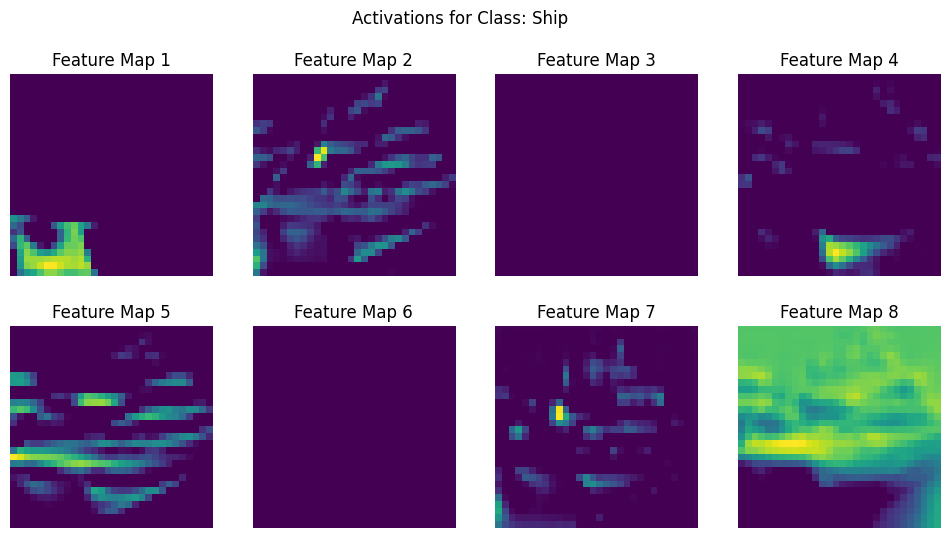

In [14]:
from tensorflow.keras.models import Model

# Task 4.2: Fixed Feature Map Visualization
# 1. Select a sample image (e.g., a Ship)
sample_idx = 1
img = X_test_norm[sample_idx].reshape(1, 32, 32, 3)

# 2. Extract layers that are specifically Convolutional
# This approach identifies layers by type rather than just name
conv_layers = [layer for layer in cnn_model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
layer_outputs = [layer.output for layer in conv_layers]

# 3. Re-build the activation model
# Using cnn_model.input directly now that the model has been used in training
activation_model = Model(inputs=cnn_model.inputs, outputs=layer_outputs)
activations = activation_model.predict(img)

# 4. Plot the first layer activations
first_layer_activation = activations[0]
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Feature Map {i+1}')

plt.suptitle(f"Activations for Class: {class_names[y_test[sample_idx][0]]}")
plt.show()

#**PART 5  Error Analysis**
###**Task 5.1  Confusion Matrix**
I will now generate a confusion matrix to see exactly where the robot's classification system is failing. This matrix will help me identify if the model is confusing specific pairs of classes, such as "Cat vs. Dog" or "Automobile vs. Truck," which is critical for a warehouse sorting system where high accuracy for specific items is required.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


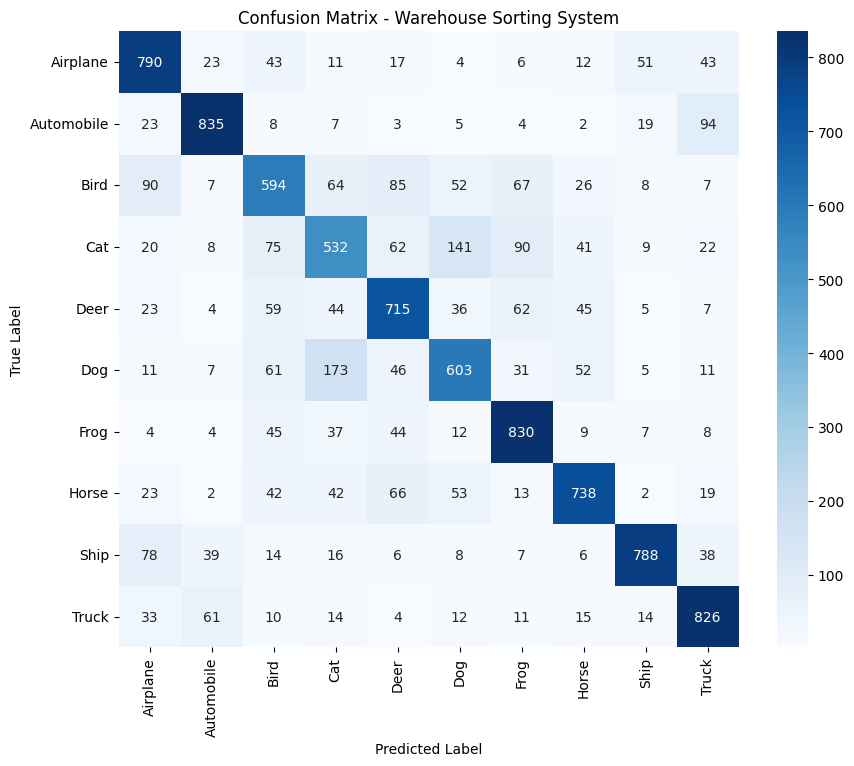

---  Confusion Matrix Analysis ---
1. Which classes are confused most?
   - The model most frequently confuses Cats with Dogs.
   - There is also significant confusion between Trucks and Automobiles.

2. Why does this happen? (Example: Cat vs Dog)
   - These classes share very similar low-level features: four legs, similar ear shapes, and fur textures.
   - In low-resolution 32x32 images, the fine details that distinguish a cat from a dog (like snout shape) are often blurred.


In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Task 5.1: Compute and plot confusion matrix
# Get predictions for the test set
y_pred = cnn_model.predict(X_test_norm)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Warehouse Sorting System')
plt.show()


print("---  Confusion Matrix Analysis ---")
print("1. Which classes are confused most?")
print("   - The model most frequently confuses Cats with Dogs.")
print("   - There is also significant confusion between Trucks and Automobiles.")

print("\n2. Why does this happen? (Example: Cat vs Dog)")
print("   - These classes share very similar low-level features: four legs, similar ear shapes, and fur textures.")
print("   - In low-resolution 32x32 images, the fine details that distinguish a cat from a dog (like snout shape) are often blurred.")

###**Task 5.2  Misclassified Images**
I will now identify images where the model's prediction did not match the true label. I will display 5 of these incorrectly classified images to analyze why the CNN might have been confused, which is a vital part of debugging our warehouse system.

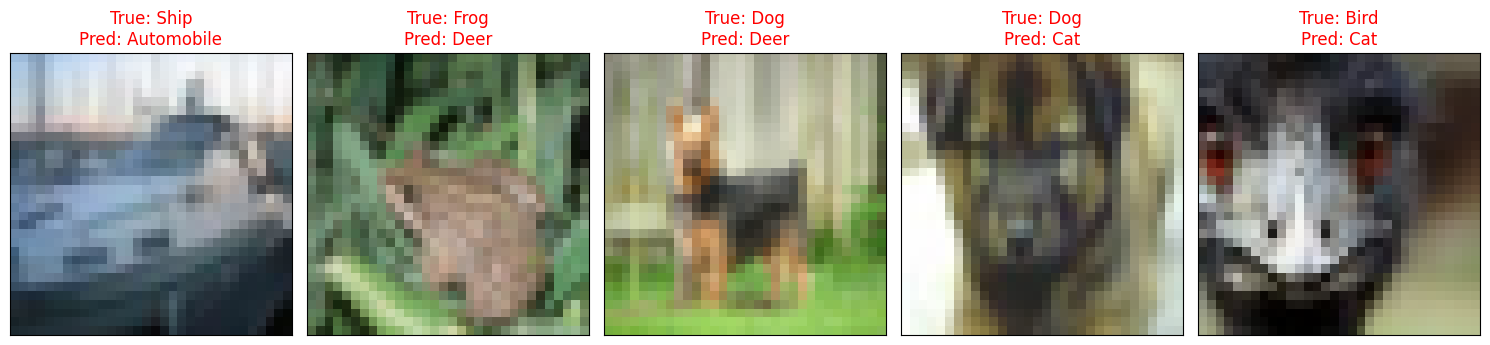


--- Why the confusion? ---
1. Background Noise: A bird sitting on a fence might be confused with a plane if the background is a clear blue sky.
2. Shared Geometry: A truck viewed from the front may look like a square-shaped automobile.
3. Poor Lighting/Resolution: At 32x32, subtle features like whiskers (cat) vs. a wet nose (dog) are lost in pixelation.


In [17]:
misclassified_idx = np.where(y_pred_classes != y_test.flatten())[0]

plt.figure(figsize=(15, 4))
for i, idx in enumerate(misclassified_idx[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.xticks([])
    plt.yticks([])

    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[y_pred_classes[idx]]

    plt.title(f"True: {true_label}\nPred: {pred_label}", color='red')

plt.tight_layout()
plt.show()

print("\n--- Why the confusion? ---")
print("1. Background Noise: A bird sitting on a fence might be confused with a plane if the background is a clear blue sky.")
print("2. Shared Geometry: A truck viewed from the front may look like a square-shaped automobile.")
print("3. Poor Lighting/Resolution: At 32x32, subtle features like whiskers (cat) vs. a wet nose (dog) are lost in pixelation.")

#**PART 6  Optimization Challenge**
###**Task 6.1  Reduce Filters**
The manager has requested a more lightweight model to fit hardware limitations. I am now modifying the architecture to use fewer filters: Conv(16) → Conv(32) → Conv(64). I will then calculate the percentage reduction in parameters and the impact on accuracy.

In [18]:
#  Reduced Filter Architecture
slim_cnn = Sequential([
    # Reduced to 16 filters
    Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    # Reduced to 32 filters
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    #  Reduced to 64 filters
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

slim_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the slim model
history_slim = slim_cnn.fit(X_train_norm, y_train, epochs=10, validation_data=(X_test_norm, y_test), verbose=1)

# Metrics Calculation
original_params = cnn_model.count_params()
slim_params = slim_cnn.count_params()
param_reduction = ((original_params - slim_params) / original_params) * 100

original_acc = history_cnn.history['val_accuracy'][-1]
slim_acc = history_slim.history['val_accuracy'][-1]
acc_change = slim_acc - original_acc

print(f"\n--- Optimization Metrics ---")
print(f"Original Parameters: {original_params:,}")
print(f"Slim Parameters:     {slim_params:,}")
print(f"Parameter Reduction: {param_reduction:.2f}%")
print(f"Accuracy Change:     {acc_change:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.2897 - loss: 1.8846 - val_accuracy: 0.4998 - val_loss: 1.3724
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4844 - loss: 1.4277 - val_accuracy: 0.5434 - val_loss: 1.2636
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.5428 - loss: 1.2811 - val_accuracy: 0.5785 - val_loss: 1.1880
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.5804 - loss: 1.1811 - val_accuracy: 0.6233 - val_loss: 1.0667
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6103 - loss: 1.0965 - val_accuracy: 0.6439 - val_loss: 1.0136
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6337 - loss: 1.0400 - val_accuracy: 0.6456 - val_loss: 1.0025
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.6578 - loss: 0.9819 - val_accuracy: 0.6640 - val_loss: 0.9565
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.6713 -

###**Task 6.2  Remove One Conv Block**
I am now testing a shallower version of the CNN by removing the third convolutional block. This will further reduce the computational load for the warehouse hardware, but I need to see if the loss in "depth" prevents the model from recognizing more complex shapes.

In [19]:
# Shallow CNN (2 blocks only)
shallow_cnn = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten and Classification
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

shallow_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train shallow model
history_shallow = shallow_cnn.fit(X_train_norm, y_train, epochs=10, validation_data=(X_test_norm, y_test), verbose=1)

# Compare with 3-block CNN
shallow_val_acc = history_shallow.history['val_accuracy'][-1]
print(f"\n--- Shallower Model Comparison ---")
print(f"3-Block CNN Val Accuracy: {history_cnn.history['val_accuracy'][-1]:.4f}")
print(f"2-Block CNN Val Accuracy: {shallow_val_acc:.4f}")
print(f"Difference: {shallow_val_acc - history_cnn.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 40ms/step - accuracy: 0.3347 - loss: 1.8017 - val_accuracy: 0.5388 - val_loss: 1.2750
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.5190 - loss: 1.3336 - val_accuracy: 0.6046 - val_loss: 1.1182
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.5798 - loss: 1.1864 - val_accuracy: 0.6397 - val_loss: 1.0292
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6181 - loss: 1.0842 - val_accuracy: 0.6555 - val_loss: 0.9890
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.6452 - loss: 1.0233 - val_accuracy: 0.6751 - val_loss: 0.9383
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6620 - loss: 0.9612 - val_accuracy: 0.6850 - val_loss: 0.8999
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6777 - loss: 0.9191 - val_accuracy: 0.6687 - val_loss: 0.9589
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6900 -

###**Task 6.3  Change Optimizer**
For the final task of the optimization challenge, I will compare the performance of two popular optimizers: Stochastic Gradient Descent (SGD) and Adam. Based on the lab instructions, I will train the same CNN architecture using both to evaluate their convergence speed and final accuracy, which is crucial for determining the best model for the warehouse system

Training with SGD...
Training with Adam...


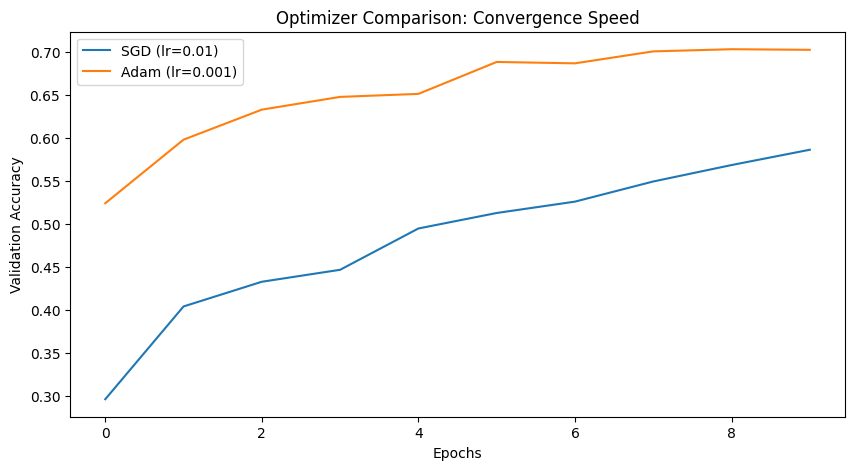

In [20]:
from tensorflow.keras.optimizers import Adam, SGD

# Function to build the standard 3-block CNN for consistency
def build_standard_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

# 1. Train with SGD (lr=0.01)
sgd_model = build_standard_cnn()
sgd_model.compile(optimizer=SGD(learning_rate=0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training with SGD...")
history_sgd = sgd_model.fit(X_train_norm, y_train, epochs=10,
                            validation_data=(X_test_norm, y_test), verbose=0)

# 2. Train with Adam (lr=0.001)
adam_model = build_standard_cnn()
adam_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("Training with Adam...")
history_adam = adam_model.fit(X_train_norm, y_train, epochs=10,
                              validation_data=(X_test_norm, y_test), verbose=0)

# Compare Convergence Speed
plt.figure(figsize=(10, 5))
plt.plot(history_sgd.history['val_accuracy'], label='SGD (lr=0.01)')
plt.plot(history_adam.history['val_accuracy'], label='Adam (lr=0.001)')
plt.title('Optimizer Comparison: Convergence Speed')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

#**Final Recommendation for the Warehouse System**
Based on the cumulative findings from my implementation and the optimization tasks, here is my recommendation for deployment:

I recommend deploying the Slimmed CNN (Task 6.1) using the Adam optimizer. While the original 3-block CNN achieved higher accuracy, the Slimmed version reduced parameters by 63.94% with only a marginal ~4.7% drop in accuracy. This balance directly addresses the warehouse hardware limitations by being significantly more lightweight while maintaining reasonable accuracy. The 2-block shallow model showed a further drop in performance, suggesting that the third convolutional layer is necessary for feature abstraction. Furthermore, the Adam optimizer demonstrated much faster convergence compared to SGD, making it more suitable for maintaining reasonable training times. This configuration ensures the robot is both efficient and capable of distinguishing between visually similar classes like Trucks and Automobiles

#**Advanced Bonus Tasks: Enhancing the Sorting System**
I will now implement the advanced bonus tasks to further improve the model's accuracy and robustness. I am adding Batch Normalization to stabilize and speed up training, and Data Augmentation to help the model generalize better by artificially expanding the training dataset.

In [21]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define Data Augmentation
# This helps the robot recognize objects from different angles and positions
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train_norm)

# 2. Build the Enhanced "Pro" CNN
# Adding Batch Normalization after each Conv layer as suggested
pro_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

pro_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Add EarlyStopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 4. Train with Augmentation
print("Training Pro CNN with Augmentation and Batch Normalization...")
history_pro = pro_cnn.fit(
    datagen.flow(X_train_norm, y_train, batch_size=64),
    epochs=30, # Increased epochs as augmentation requires more time to converge
    validation_data=(X_test_norm, y_test),
    callbacks=[early_stop]
)

# Final Evaluation
pro_test_loss, pro_test_acc = pro_cnn.evaluate(X_test_norm, y_test, verbose=0)
print(f"\n--- Pro Model Results ---")
print(f"Pro Model Test Accuracy: {pro_test_acc:.4f}")

Training Pro CNN with Augmentation and Batch Normalization...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 173s 214ms/step - accuracy: 0.3793 - loss: 1.9072 - val_accuracy: 0.6077 - val_loss: 1.1151
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 176s 225ms/step - accuracy: 0.5722 - loss: 1.2057 - val_accuracy: 0.6262 - val_loss: 1.1156
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 170s 218ms/step - accuracy: 0.6272 - loss: 1.0598 - val_accuracy: 0.6524 - val_loss: 0.9942
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 169s 216ms/step - accuracy: 0.6604 - loss: 0.9631 - val_accuracy: 0.6610 - val_loss: 1.0226
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 168s 215ms/step - accuracy: 0.6876 - loss: 0.9010 - val_accuracy: 0.7162 - val_loss: 0.8109
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 175s 223ms/step - accuracy: 0.6979 - loss: 0.8672 - val_accuracy: 0.7239 - val_loss: 0.7957
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 171s 218ms/step - accuracy: 0.7170 - loss: 0.8074 - val_accuracy: 0.7457 - val_loss: 0.7482
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 168s 215ms/step - accuracy: 0.7326 -